# Análisis de perfiles clínicos asociados al estado de la microbiota intestinal mediante aprendizaje no supervisado

### Autores:
Ana Paulina Delgadillo Bustos, Evelin Sarahi Corona Corona, Ana Julia Ceja Rodriguez, German Preciat

## Descripción del proyecto

Este proyecto tiene como objetivo explorar el estado de la microbiota intestinal sin recurrir a técnicas de secuenciación, utilizando únicamente variables clínicas, fisiológicas y de estilo de vida obtenidas mediante encuestas y mediciones básicas.

a través de herramientas de análisis de datos e inteligencia artificial, se busca identificar patrones ocultos en la población, así como perfiles clínicos asociados a posibles estados de equilibrio o disbiosis de la microbiota.

## Objetivo

Identificar estructuras latentes en los datos que permitan caracterizar distintos perfiles de microbiota a partir de variables no invasivas, contribuyendo al desarrollo de herramientas accesibles para la evaluación del estado de salud intestinal.

## Importancia

* Enfoque no invasivo
* Integración de biomatemáticas e inteligencia artificial
* Potencial aplicación clínica y preventiva
* Base para futuros modelos predictivos de microbiota


## Nota

Los resultados presentados corresponden a un análisis exploratorio y deben interpretarse como hipótesis generadoras, sujetas a validación clínica y experimental posterior.


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 01 Librerías utilizadas

En este proyecto utilizamos herramientas especializadas para análisis de datos, visualización y aprendizaje automático.

### Manipulación y análisis de datos
* Pandas: permite leer archivos y trabajar con datos en formato tabular.
* Numpy: facilita cálculos numéricos y operaciones matemáticas

### Visualización de datos
* Matplotlib: base para generar gráficas
* Seaborn: mejora la estética y permite visualizaciones estadísticas más avanzadas

### Machine learning y análisis biomédico
* Standardscaler: estandariza las variables (z-score) para hacerlas comparables
* Pca (principal component analysis): reduce la dimensionalidad y permite visualizar los datos en 2d
* Gaussian mixture model: algoritmo de clustering para identificar perfiles clínicos
* Isolation forest: detecta pacientes atípicos dentro de la población

In [6]:
import pandas as pd
import re
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import IsolationForest

## 02 Carga de datos

En este paso se carga el archivo de datos que contiene toda la información recolectada de los participantes.

Posteriormente se realiza una visualización inicial para verificar que los datos se hayan cargado correctamente y entender la estructura de la base de datos.

In [7]:
# Cargar los datos
datos_registro = pd.read_excel('Microbiota_ Formulario de Equipo_Registros.xlsx')

# Visualizar los datos
datos_registro.head(113)

,ID Registro,Fecha Registro,Estatura (cm),Peso (kg),Temperatura (°C),Circunferencia Abdominal (cm),Frecuencia Cardíaca (BPM),Centro Universitario,pH Salival,Glucosa en Sangre (Mg/dL),Fitzpatrick Scale
0,1,2026-02-17 12:37:44,153.0,57,36.2,78.0,78,CUCEI,8,84 Después de desayuno,2
1,2,2026-02-17 12:37:59,173.0,80,36.3,89.0,93,CUCEI,7,109 Después de desayuno,2
2,3,2026-02-17 12:40:12,164.0,47,36.4,63.0,111,CUCEI,7,117 Después de desayuno,4
3,4,2026-02-17 12:40:20,157.0,51.5,36.2,73.0,95,CUCEI,8,88 Después de desayuno,3
4,5,2026-02-17 12:40:50,169.0,60.8,36.2,73.0,86,CUCEI,7,97 Después de desayuno,2
...,...,...,...,...,...,...,...,...,...,...,...
106,107,2025-12-04 10:41:31,172.0,89,35.9,97.5,81,CUCEI,8,84,4
107,108,2025-12-04 10:35:32,180.0,84,35.8,90.0,102,CUCEI,7,91,2
108,109,2025-12-04 10:26:07,172.0,95.5,36.0,110.0,94,CUCEI,7,100,4
109,110,2025-12-04 10:16:09,170.0,62,35.6,83.0,86,CUCEI,7,80 desayunó,3


## 03 Carga de datos del formulario

En este paso se carga el archivo del formulario que contiene las respuestas de los participantes.

Posteriormente se visualizan los datos para verificar que se hayan cargado correctamente y observar la estructura de las columnas.

In [8]:
archivo = '/content/Cómo está tu microbiota.xlsx'
datos_formulario = pd.read_excel(archivo)

# visualizar datos
datos_formulario.head(113)

,Marca temporal,Por favor anota aquí el número que se te fue asignado,1.1 Fecha de nacimiento,1.2 Sexo Biológico,1.3 ¿Naciste por cesárea? (La vía de nacimiento influye en la composición inicial del microbioma),"1.4 ¿Alguno de tus padres o abuelos nació en otro país? (La ascendencia puede influir en el microbioma debido a factores genéticos, culturales y dietéticos heredados)","1.5 En caso de haber respondido afirmativamente, por favor especifica el país o región correspondiente.",2.1 ¿Cuántos días a la semana realizas actividad física moderada o intensa (mínimo 30 minutos)?,2.2 ¿Qué tipo de actividad física realizas con mayor frecuencia? (Puedes marcar más de una),2.3 ¿Hace cuánto tiempo mantienes tu rutina actual de ejercicio?,...,6.9 ¿Con qué frecuencia te cepilla los dientes al día?,6.10 ¿Utilizas enjuague bucal?,6.11 ¿Con qué frecuencia en la última semana sentiste que no podías controlar las cosas importantes de tu vida?,"6.12 ¿Con qué frecuencia en la última semana tuviste tensión muscular, dolor de cuello o mandíbula apretada?","6.13 ¿Qué tan seguido en la última semana tuviste problemas digestivos relacionados con estrés (hinchazón, diarrea, estreñimiento)?",6.14 ¿Con qué frecuencia has tenido dificultades para relajarte?,6.15 ¿Con qué frecuencia sientes que estás bajo demasiada presión o exigencias?,7.1 ¿Tu ciclo menstrual es regular?,7.2 Duración aproximada del ciclo menstrual (días entre una menstruación y otra),7.3 Duración promedio de la menstruación (sangrado)
0,2026-02-09 13:00:35.248,49,2004-01-08 00:00:00,Hombre,Sí,No,NaN,1 a 2 días,Caminar,1 a 6 meses,...,3 veces o más,No lo utilizo,2 = Frecuentemente,1 = A veces,1 = Rara vez,2 = A menudo,2 = Frecuentemente,No aplica,No aplica,No aplica
1,2026-02-09 15:35:16.000,52,2026-02-09 00:00:00,Hombre,Sí,No,-,3 a 4 días,"Caminar, Correr",1 año o más,...,3 veces o más,"Sí, ocasionalmente",1 = A veces,2 = Frecuentemente,1 = Rara vez,2 = A menudo,1 = Algunas veces,No aplica,No aplica,No aplica
2,2026-02-17 12:28:34.123,2,2004-08-16 00:00:00,Mujer,Sí,No,NaN,1 a 2 días,"Pesas, Baile",Menos de 1 mes,...,3 veces o más,No lo utilizo,2 = Frecuentemente,2 = Frecuentemente,1 = Rara vez,1 = A veces,2 = Frecuentemente,A veces irregular,25–31 días,3 a 5 días
3,2026-02-17 12:31:29.676,1,2004-07-27 00:00:00,Mujer,Sí,No,NaN,1 a 2 días,"Natación, Pesas",1 año o más,...,3 veces o más,No lo utilizo,2 = Frecuentemente,2 = Frecuentemente,1 = Rara vez,2 = A menudo,2 = Frecuentemente,"Sí, siempre regular",25–31 días,3 a 5 días
4,2026-02-17 12:34:15.610,3,2003-12-12 00:00:00,Mujer,Sí,No,NaN,5 o más días,"Caminar, Pesas",6 a 12 meses,...,3 veces o más,"Sí, varias veces por semana",1 = A veces,0 = Nunca,1 = Rara vez,2 = A menudo,2 = Frecuentemente,A veces irregular,25–31 días,6 a 7 días
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,2025-12-04 10:54:56.339,107,2004-01-06 00:00:00,Hombre,Sí,No,NaN,3 a 4 días,"Correr, Pesas",1 a 6 meses,...,2 veces,No lo utilizo,1 = A veces,2 = Frecuentemente,0 = Nunca,1 = A veces,2 = Frecuentemente,No aplica,No aplica,No aplica
107,2025-12-04 10:16:15.013,108,2004-06-10 00:00:00,Hombre,No,No,NaN,3 a 4 días,"Caminar, Pesas",1 a 6 meses,...,3 veces o más,No lo utilizo,0 = Nunca,0 = Nunca,0 = Nunca,0 = Nunca,1 = Algunas veces,No aplica,No aplica,No aplica
108,2025-12-04 10:05:52.727,109,2003-07-25 00:00:00,Hombre,Sí,No,NaN,Nunca,Pesas,Menos de 1 mes,...,2 veces,No lo utilizo,1 = A veces,0 = Nunca,0 = Nunca,1 = A veces,1 = Algunas veces,No aplica,No aplica,No aplica
109,2025-12-04 09:58:41.836,110,2002-07-13 00:00:00,Hombre,Sí,No,NaN,1 a 2 días,"Caminar, Correr",6 a 12 meses,...,2 veces,"Sí, ocasionalmente",3 = Muy frecuentemente,2 = Frecuentemente,0 = Nunca,1 = A veces,1 = Algunas veces,No aplica,No aplica,No aplica


## 04 Integración y limpieza de datos

En este paso se realiza la integración de las dos fuentes de datos: el formulario y los registros clínicos.

Primero se estandarizan los identificadores de cada participante para asegurar una correcta correspondencia entre ambas tablas. Posteriormente, se realiza una unión de los datos conservando únicamente los registros coincidentes en ambas fuentes.

Finalmente, se genera un pequeño diagnóstico para verificar que la unión fue exitosa.

In [9]:
# nombres de columnas de identificación
columna_id_form = 'Por favor anota aquí el número que se te fue asignado'
columna_id_reg = 'ID Registro'

# función para estandarizar IDs a formato de 3 dígitos
def formatear_id(valor):
    if pd.isna(valor):
        return ""
    texto = str(valor).replace('.0', '').strip()
    return texto.zfill(3)

# crear columna de unión en ambos datasets
datos_formulario['id_match'] = datos_formulario[columna_id_form].apply(formatear_id)
datos_registro['id_match'] = datos_registro[columna_id_reg].apply(formatear_id)

# unir datasets
df_final = pd.merge(
    datos_formulario,
    datos_registro,
    on='id_match',
    how='inner'
).reset_index(drop=True)

df_final.index += 1  # índice desde 1

# diagnóstico de unión
print("--- reporte de unión de archivos ---")
print(f"total formulario: {len(datos_formulario)}")
print(f"total registros:  {len(datos_registro)}")
print(f"uniones exitosas: {len(df_final)}\n")

# verificación visual
columnas_verificacion = ['id_match', columna_id_form, columna_id_reg]
print("--- muestra de datos unidos ---")
print(df_final[columnas_verificacion].head(113))

--- reporte de unión de archivos ---
total formulario: 111
total registros:  111
uniones exitosas: 111

--- muestra de datos unidos ---
    id_match  Por favor anota aquí el número que se te fue asignado  \
1        049                                                 49       
2        052                                                 52       
3        002                                                  2       
4        001                                                  1       
5        003                                                  3       
..       ...                                                ...       
107      107                                                107       
108      108                                                108       
109      109                                                109       
110      110                                                110       
111      111                                                111       

     ID Reg

## 05 Limpieza y estandarización de variables numéricas

En esta etapa se identifican las variables que deben ser numéricas y se corrigen posibles errores de captura.
Muchos valores pueden venir como texto (por ejemplo "170 cm" o "70kg"), por lo que es necesario extraer únicamente el valor numérico.

Posteriormente, se realiza imputación de datos faltantes:

* Para variables continuas (peso, estatura, circunferencia) se usa la media
* Para variables clínicas o categóricas se usa la mediana, ya que es más robusta a valores extremos

Esto asegura que el dataset esté completo y listo para análisis estadístico y modelos de IA.

In [10]:
# limpiar nombres de columnas
df_final.columns = df_final.columns.str.strip()

cols_numericas = [
    'Peso (kg)', 'Estatura (cm)', 'Temperatura (°C)',
    'Circunferencia Abdominal (cm)', 'Frecuencia Cardíaca (BPM)',
    'pH Salival', 'Glucosa en Sangre (Mg/dL)', 'Fitzpatrick Scale',
    '4.1 ¿Cuál de las siguientes imágenes representa mejor el tipo de heces que tienes la mayoría de los días?',
    '6.9  ¿Con qué frecuencia te cepilla los dientes al día?'
]

def limpiar_numeros(valor):
    if isinstance(valor, str):
        numeros = re.findall(r"[-+]?\d*\.\d+|\d+", valor)
        return float(numeros[0]) if numeros else np.nan
    return valor

cols_validas = [col for col in cols_numericas if col in df_final.columns]

for col in cols_validas:
    df_final[col] = df_final[col].apply(limpiar_numeros)

    if col in ['Peso (kg)', 'Estatura (cm)', 'Circunferencia Abdominal (cm)']:
        df_final[col] = df_final[col].fillna(df_final[col].mean())
    else:
        df_final[col] = df_final[col].fillna(df_final[col].median())

print(df_final[['id_match'] + cols_validas].head(113))

    id_match  Peso (kg)  Estatura (cm)  Temperatura (°C)  \
1        049       73.0          178.0              36.0   
2        052       72.0          175.0              36.4   
3        002       80.0          173.0              36.3   
4        001       57.0          153.0              36.2   
5        003       47.0          164.0              36.4   
..       ...        ...            ...               ...   
107      107       89.0          172.0              35.9   
108      108       84.0          180.0              35.8   
109      109       95.5          172.0              36.0   
110      110       62.0          170.0              35.6   
111      111       50.0          161.0              36.7   

     Circunferencia Abdominal (cm)  Frecuencia Cardíaca (BPM)  pH Salival  \
1                             87.5                         80         7.0   
2                             77.0                         83         9.0   
3                             89.0              

## 06 Transformación de variables categóricas a formato numérico

En esta etapa se convierten las respuestas categóricas del cuestionario en valores numéricos.

Esto es fundamental porque los modelos de análisis de datos y aprendizaje automático no pueden trabajar directamente con texto.

La estrategia utilizada es:

* Definir diccionarios de mapeo para cada tipo de pregunta
estandarizar texto (minúsculas, sin espacios)
* Convertir cada respuesta a su valor numérico correspondiente
* Renombrar columnas para simplificar el análisis
* Manejar casos especiales (valores abiertos como “4 o más”)
* Transformar preguntas de selección múltiple usando one-hot encoding

Esto permite construir una matriz de datos completamente numérica, consistente y lista para modelado.

In [11]:
mapa_si_no = {
    'sí': 1, 'si': 1, 'no': 0,
    'no lo hago': 0, 'no lo utilizo': 0, 'no consumo': 0, 'no aplica': 0
}

mapa_frecuencia_dias = {
    'nunca': 0,
    '1 a 2 días': 1, '1 a 2 dias': 1,
    '3 a 4 días': 2, '3 a 4 dias': 2,
    '5 o más días': 3, '5 o mas dias': 3, '5 o más dias': 3
}

mapa_antiguedad = {
    'menos de 1 mes': 0, '1 a 6 meses': 1, '6 a 12 meses': 2, '1 año o más': 3, '1 año o mas': 3
}

mapa_horas_sedentarias = {
    'menos de 4 horas': 0, '4 a 6 horas': 1, '7 a 9 horas': 2, 'más de 9 horas': 3, 'mas de 9 horas': 3
}

mapa_ayuno = {
    'menos de 8 horas': 0, '8 a 10 horas': 1, '10 a 12 horas': 2, 'más de 12 horas': 3
}

mapa_tiempo_comidas = {
    'menos de 2 horas': 0, '2 a 4 horas': 1, '4 a 6 horas': 2, 'más de 6 horas': 3
}

mapa_porciones = {
    '0': 0, '1 a 2': 1, '3 a 4': 2, '5 o más': 3, '5 o mas': 3
}

mapa_fermentados = {
    'nunca': 0, 'rara vez (1 vez al mes o menos)': 1,
    'ocasionalmente (2 a 4 veces al mes)': 2, 'frecuentemente (1 o más veces por semana)': 3
}

mapa_fibra = {
    'nunca': 0, '1 a 2 veces por semana': 1, '3 a 5 veces por semana': 2, 'diario': 3
}

mapa_dieta = {
    'omnívora (consume de todo)': 0, 'omnivora (consume de todo)': 0,
    'vegetariana': 1, 'vegana': 2, 'pescetariana': 3,
    'cetogénica / baja en carbohidratos': 4, 'mediterránea': 5
}

mapa_uso_frec = {
    'no consumo': 0, 'no lo utilizo': 0,
    'sí, ocasionalmente': 1, 'si, ocasionalmente': 1,
    'sí, varias veces por semana': 2, 'si, varias veces por semana': 2,
    'sí, diariamente': 3, 'si, diariamente': 3
}

mapa_evacuacion = {
    'menos de 3 veces por semana': 0, '3 veces por semana a una vez al día': 1,
    '2 a 3 veces al día': 2, 'más de 3 veces al día': 3
}

mapa_enfermedad_anual = {
    '1 vez': 1, '2  a 3 veces': 2, '2 a 3 veces': 2, '4 o más veces': 3
}

mapa_sueno_horas = {
    '5 o menos': 0, '5 a 6 horas': 1, '7 a 8 horas': 2, 'más de 8 horas': 3
}

mapa_estres = {
    'bajo': 1, 'moderado': 2, 'alto': 3, 'muy alto': 4
}

mapa_habitos_nocivos = {
    'nunca': 0, 'ocasionalmente (menos de 1 vez al mes)': 1,
    'mensualmente (1 a 3 veces al mes)': 2, 'semanalmente (1–3 veces por semana)': 3,
    'frecuentemente (4 o más veces por semana)': 4
}

mapa_calidad_sueno = {
    'muy mala': 1, 'mala': 2, 'adecuada': 3, 'buena': 4, 'excelente': 5
}

mapa_psico = {
    '0 = nunca': 0,
    '1 = a veces': 1, '1 = rara vez': 1, '1 = algunas veces': 1,
    '2 = frecuentemente': 2, '2 = varias veces': 2, '2 = a menudo': 2,
    '3 = muy frecuentemente': 3, '3 = casi todos los días': 3, '3 = muy a menudo': 3, '3 = todos los días': 3
}

mapa_ciclo_reg = {
    'no aplica': 0, 'muy irregular / no tengo ciclo': 1,
    'a veces irregular': 2, 'sí, siempre regular': 3
}

mapa_ciclo_dur = {
    'no aplica': 0, 'menos de 24 días': 1, '25–31 días': 2, 'más de 32 días': 3
}

mapa_sangrado = {
    'no aplica': 0, '1 a 2 días': 1, '3 a 5 días': 2, '6 a 7 días': 3, 'más de 7 días': 4
}

configuracion = [
    ('1.3', mapa_si_no), ('1.4', mapa_si_no),
    ('2.1', mapa_frecuencia_dias), ('2.3', mapa_antiguedad), ('2.4', mapa_horas_sedentarias),
    ('3.1', mapa_ayuno), ('3.3', mapa_tiempo_comidas), ('3.4', mapa_porciones),
    ('3.5', mapa_frecuencia_dias), ('3.6', mapa_fermentados), ('3.8', mapa_fibra),
    ('3.9', mapa_dieta), ('3.10', mapa_si_no), ('3.12', mapa_uso_frec),
    ('4.2', mapa_evacuacion), ('5.1', mapa_enfermedad_anual),
    ('5.3', mapa_si_no), ('5.4', mapa_si_no), ('5.7', mapa_si_no),
    ('6.1', mapa_sueno_horas), ('6.2', mapa_estres), ('6.3', mapa_si_no),
    ('6.4', mapa_habitos_nocivos), ('6.5', mapa_si_no), ('6.6', mapa_habitos_nocivos),
    ('6.7', mapa_calidad_sueno), ('6.8', mapa_si_no), ('6.10', mapa_uso_frec),
    ('6.11', mapa_psico), ('6.12', mapa_psico), ('6.13', mapa_psico),
    ('6.14', mapa_psico), ('6.15', mapa_psico),
    ('7.1', mapa_ciclo_reg), ('7.2', mapa_ciclo_dur), ('7.3', mapa_sangrado)
]

cols_listas = []

print("\n--- INICIANDO MAPEADO DE PREGUNTAS CATEGÓRICAS ---")

for id_col, mapa in configuracion:
    coincidencias = [col for col in df_final.columns if str(col).strip().startswith(id_col)]

    if coincidencias:
        col_real = coincidencias[0]
        df_final[col_real] = df_final[col_real].astype(str).str.lower().str.strip()
        df_final[col_real] = df_final[col_real].map(mapa)
        df_final.rename(columns={col_real: id_col}, inplace=True)
        cols_listas.append(id_col)

cols_32 = [c for c in df_final.columns if str(c).strip().startswith('3.2')]
if cols_32:
    col_real = cols_32[0]
    df_final[col_real] = df_final[col_real].astype(str).replace({'4 o más': '4', '4 o mas': '4'})
    df_final[col_real] = pd.to_numeric(df_final[col_real], errors='coerce')
    df_final.rename(columns={col_real: '3.2'}, inplace=True)
    cols_listas.append('3.2')

cols_multiples_config = [('2.2', 'Act_'), ('5.6', 'Sint_')]
cols_generadas = []

for id_col, prefijo in cols_multiples_config:
    coincidencias = [col for col in df_final.columns if str(col).strip().startswith(id_col)]
    if coincidencias:
        col_real = coincidencias[0]
        dummies = df_final[col_real].str.get_dummies(sep=', ').add_prefix(prefijo)
        cols_generadas.extend(dummies.columns.tolist())
        df_final = pd.concat([df_final, dummies], axis=1)

print("Columnas categóricas mapeadas a valores numéricos.")

cols_listas.sort(key=lambda s: [int(u) for u in s.split('.') if u.isdigit()])

columnas_finales = ['id_match'] + cols_listas + cols_generadas
cols_a_imprimir = [c for c in columnas_finales if c in df_final.columns]

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_rows', 20)

print("\n--- TABLA RESULTANTE (Categóricas Mapeadas) ---")
print(df_final[cols_a_imprimir].head(113))


--- INICIANDO MAPEADO DE PREGUNTAS CATEGÓRICAS ---
Columnas categóricas mapeadas a valores numéricos.

--- TABLA RESULTANTE (Categóricas Mapeadas) ---
    id_match  1.3  1.4  2.1  2.3  2.4  3.1  3.2  3.3  3.4  3.5  3.6  3.8  3.9  3.10  3.12  4.2  5.1  5.3  5.4  5.7  6.1  6.2  6.3  6.4  6.5  6.6  6.7  6.8  6.10  6.11  6.12  6.13  6.14  6.15  7.1  7.2  7.3  Act_Baile  Act_Basquetbol   Act_Caminar  Act_Ciclismo  Act_Correr  Act_Danza aerea y pole dance  Act_Ejercicio de pesas en casa + bici estática   Act_Estiramientos aerobicos  Act_Futbol  Act_Futbol   Act_Fútbol  Act_Gym literal de todos los aparatos es fortalecimiento físico   Act_Natación  Act_Pesas  Act_Pilates   Act_Saltar cuerda  Act_Saltar la cuerda  Act_Yoga  Sint_Diarrea  Sint_Dolor abdominal  Sint_Estreñimiento  Sint_Gases  Sint_Hinchazón  Sint_Ninguno
1        049    1    0    1    1    1    1    3    2    1    2    0    2    0     1     0    2    2    0    0    0    0    3    0    1    1    1    3    1     0     2     1    

### 07 Procesamiento de respuestas abiertas

Se identifican las preguntas abiertas del formulario y se renombran a etiquetas más manejables.
Posteriormente, se realiza una limpieza básica del texto para estandarizar los datos.

* Conversión a minúsculas
* Eliminación de espacios innecesarios
* Limpieza de valores vacíos provenientes de Excel

Este paso permite mantener información cualitativa lista para análisis posterior

In [12]:
# Definimos cuáles son las preguntas abiertas y qué nombre corto queremos
config_texto = [
    ('3.7', '3.7_Fermentado_Tipo'),
    ('3.11', '3.11_Probiotico_Tipo'),
    ('5.2', '5.2_Enfermedad_Tipo'),
    ('5.5', '5.5_Enfermedad_Digestiva_Tipo')
]

cols_texto_listas = []

for id_col, nuevo_nombre in config_texto:
    # Buscamos la columna que empiece con el número
    coincidencias = [col for col in df_final.columns if str(col).strip().startswith(id_col)]

    if coincidencias:
        col_real = coincidencias[0]

        # LIMPIEZA DE TEXTO:
        # 1. Convertir a string, minúsculas, quitar espacios
        df_final[col_real] = df_final[col_real].astype(str).str.lower().str.strip()
        # 2. Limpiar valores vacíos o ceros que vienen del Excel
        df_final[col_real] = df_final[col_real].replace({'nan': '', '0': '', '0.0': ''})

        # Renombrar
        df_final.rename(columns={col_real: nuevo_nombre}, inplace=True)
        cols_texto_listas.append(nuevo_nombre)

    else:
        print(f"No se encontró la columna de texto: {id_col}")

# Visualización solo del texto

# Unimos ID + Columnas de Texto
cols_ver_texto = ['id_match'] + cols_texto_listas
cols_existentes = [c for c in cols_ver_texto if c in df_final.columns]

pd.set_option('display.max_colwidth', 50)

print("\n--- TABLA DE RESPUESTAS ABIERTAS ---")
print(df_final[cols_existentes].head(13))


--- TABLA DE RESPUESTAS ABIERTAS ---
   id_match       3.7_Fermentado_Tipo 3.11_Probiotico_Tipo                      5.2_Enfermedad_Tipo           5.5_Enfermedad_Digestiva_Tipo
1       049                                         yekult                                    gripa                                        
2       052  kombucha, yogurt natural                    -                                    gripe                                       -
3       002                     kefir                            gripas, infecciones en la garganta              colitis auto diagnosticada
4       001     yogur, soful, y kéfir                kéfir                                    gripe                                 colitis
5       003             yogurt griego                                                         gripa                                        
6       004             yogurt griego             inositol                                    gripa                       

### 08 Creación de variables fisiológicas y scores clínicos

En esta sección se generan variables derivadas a partir de los datos originales con el objetivo de capturar patrones fisiológicos complejos.

Se construyen indicadores clave:

* IMC (Índice de Masa Corporal) → estado antropométrico
* Taquicardia en reposo → estrés fisiológico
* Diet Score → calidad de la alimentación
* Microbiota Stress → agresiones al sistema digestivo
* Lifestyle Score → estilo de vida global
* Riesgo de cintura → obesidad central (criterios IDF)
* Categoría de glucosa → riesgo metabólico ajustado por ayuno
* Metabolic Risk Score → integración de riesgo metabólico

⚠️ Nota: Estos scores son heurísticos y exploratorios. No tienen finalidad diagnóstica.

Finalmente, se eliminan variables redundantes para evitar sesgos en modelos de clustering.

In [13]:
print("\n--- CREANDO VARIABLES FISIOLÓGICAS Y SCORES ---")

# 1. Índice de masa corporal (IMC)
# Verificamos que tengamos los datos crudos antes de intentar calcular
if 'Peso (kg)' in df_final.columns and 'Estatura (cm)' in df_final.columns:
    # Fórmula clínica: Peso (kg) / [Estatura (m)]^2
    # Dividimos la estatura entre 100 para pasar de centímetros a metros.
    # El operador '**2' en Python significa "elevar al cuadrado".
    df_final['IMC'] = df_final['Peso (kg)'] / (df_final['Estatura (cm)'] / 100)**2
    print("IMC calculado.")

# 2. Estrés fisiológico (Taquicardia en Reposo)
if 'Frecuencia Cardíaca (BPM)' in df_final.columns:
    # Creamos una variable binaria (1 o 0).
    # Si los latidos superan los 90 BPM, la condición es Verdadera (True = 1).
    # .astype(int) convierte ese True/False en números 1/0 para que el modelo lo entienda.
    df_final['Taquicardia_reposo'] = (df_final['Frecuencia Cardíaca (BPM)'] > 90).astype(int)

# 3. DIET SCORE (Calidad de la Dieta para la Microbiota)
# Usamos df_final.get('columna', valor_por_defecto) por seguridad. Si no halla la columna, usa 0.
# .fillna(0) asegura que si un paciente dejó la pregunta en blanco (NaN), se cuente como 0.
# LÓGICA: Sumamos los protectores (multiplicados por 2 por su alta importancia)
# y restamos los agresores (ultraprocesados x2, edulcorantes x1).
df_final['Diet_Score'] = (
    df_final.get('3.8', 0).fillna(0) * 10 +  # Suma: Fibra (Prebiótico principal)
    df_final.get('3.6', 0).fillna(0) * 7 -  # Suma: Fermentados + Probióticos. El menos final es para la sig. línea.
    df_final.get('3.5', 0).fillna(0) * 9 -  # Resta: Fibra + Fermentados - Ultraprocesados (Agresor severo)
    df_final.get('3.12', 0).fillna(0)* 8    # Resta: Fibra + Fermentados - Ultraprocesados - Edulcorantes (Agresor moderado)
)
# 4. MICROBIOTA STRESS (Índice de Destrucción Bacteriana)
# Este score mide agresiones clínicas directas. Un número alto es malo.

df_final['Microbiota_Stress'] = (
    df_final.get('5.3', 0).fillna(0) * 10 +  # Ataque severo a la microbiota
    df_final.get('5.7', 0).fillna(0) * 9 +   # Infección directa al tracto GI
    df_final.get('5.1', 0).fillna(0) * 4     # Estrés inmunológico sistémico
)
# 5. LIFESTYLE SCORE (Estilo de Vida Global)
# Lógica del sueño: La escala original es 1 (Muy mala) a 5 (Excelente).
# Si restamos nuestro valor a 5 (ej. 5 - 5 = 0 riesgo; 5 - 1 = 4 de riesgo),
# invertimos la escala para que un número alto signifique "Mal sueño".
mal_sueno = 5 - df_final.get('6.7', 3).fillna(3)

# Lógica del SCORE: Partimos de lo bueno (Ejercicio) y le vamos restando los malos hábitos.
# Si el resultado es negativo, el paciente tiene un estilo de vida de alto riesgo.
df_final['Lifestyle_Score'] = (
    df_final.get('2.1', 0).fillna(0) * 8 -  # Ejercicio suma puntos a favor
    df_final.get('2.4', 0).fillna(0) * 7 -      # El sedentarismo resta
    df_final.get('6.2', 0).fillna(0) * 9 -      # El estrés resta
    mal_sueno                               # El mal sueño calculado arriba resta
)
# 6. Riesgo por Circunferencia Abdominal (Criterios IDF)
def riesgo_cintura(row):
    # Intentamos obtener la cintura. Si está vacía (NaN), devolvemos NaN.
    cintura = row.get('Circunferencia Abdominal (cm)', np.nan)
    if pd.isna(cintura):
        return np.nan

    # Buscamos el sexo usando el nombre de la columna
    # (Usamos .get() por seguridad, por si a algún paciente le falta el dato)
    sexo = str(row.get('Sexo Biológico', '')).lower()

    # Aplicamos los criterios de la Int. Diabetes Federation (IDF)
    if 'mujer' in sexo or 'femenina' in sexo:
        return int(cintura >= 80) # Límite de riesgo en mujeres
    elif 'hombre' in sexo or 'masculino' in sexo:
        return int(cintura >= 94) # Límite de riesgo en hombres

    # Si el paciente no indicó sexo, usamos 90cm como límite precautorio general.
    return int(cintura >= 90)

# .apply(axis=1) ejecuta la función fila por fila (paciente por paciente)
df_final['Riesgo_cintura'] = df_final.apply(riesgo_cintura, axis=1)

# 7. Riesgo glucémico ajustado (Evitando Falsos Positivos)
def clasificacion_glucosa_ajustada(row):
    glucosa = row.get('Glucosa en Sangre (Mg/dL)', np.nan)
    ayuno = row.get('3.1', np.nan) # Rescata las horas de ayuno (0 = postprandial)

    if pd.isna(glucosa):
        return np.nan

    # CASO A: El paciente comió hace menos de 8 horas (Postprandial)
    if ayuno == 0:
        if glucosa < 140: return 0         # Los picos bajo 140 son normales si acabas de comer
        elif 140 <= glucosa < 200: return 1 # Tolerancia alterada
        else: return 2                     # Sospecha de Diabetes

    # CASO B: El paciente tiene 8 horas o más de ayuno (Basal / Clínico)
    else:
        if glucosa < 100: return 0         # Límite normal en ayunas
        elif 100 <= glucosa < 126: return 1 # Rango de Prediabetes
        else: return 2                     # Sospecha de Diabetes

# Solo aplicamos la función si existen ambas columnas para no causar errores
if 'Glucosa en Sangre (Mg/dL)' in df_final.columns and '3.1' in df_final.columns:
    df_final['Categoria_Glucosa'] = df_final.apply(clasificacion_glucosa_ajustada, axis=1)
    print("Categoría de Glucosa calculada y ajustada por horas de ayuno.")

# 8. SCORE METABÓLICO final
# Mezclamos los tres grandes indicadores metabólicos.
# El IMC se multiplica por 0.3 para escalarlo y que no "aplaste" a los otros dos riesgos.

# JUSTIFICACIÓN MATEMÁTICA Y CLÍNICA DE LOS MULTIPLICADORES (0.3 y 2):
# Problema de escala: El IMC maneja números "grandes" (ej. 20 a 40), mientras que
# Cintura y Glucosa manejan números "pequeños" (0, 1 o 2). Si los sumáramos directo,
# el peso de un paciente opacaría por completo sus alertas clínicas de diabetes.
#
# Solución (Equilibrio):
# * IMC * 0.3 (Reductor): Encoge matemáticamente el valor del IMC para que sirva
#   solo como una base (ej. un IMC de 30 aporta 9 puntos al score final).
# * Cintura y Glucosa * 2 (Amplificador): Tener obesidad visceral o hiperglucemia
#   son alertas rojas absolutas del Síndrome Metabólico. Al multiplicarlas por 2,
#   forzamos a que estas variables disparen el puntaje final, dándoles el peso médico real.
df_final['Metabolic_Risk_Score'] = (
    df_final.get('IMC', 25).fillna(25) * 0.3 +       # IMC Base (asumimos 25 si está vacío)
    df_final.get('Riesgo_cintura', 0).fillna(0) * 2 + # +2 puntos si tiene obesidad central
    df_final.get('Categoria_Glucosa', 0).fillna(0) * 2 # +2 o +4 puntos si hay problemas de glucosa
)
print("Scores clínicos multivariables generados con éxito.")

# 9. Reducción de dimensionalidad (Eliminar Redundancias)
# El modelo K-Means se confunde si le damos los "ingredientes" y el "pastel" al mismo tiempo.
# Borramos las variables base porque ya fueron absorbidas por nuestros nuevos Súper Scores.

columnas_redundantes = [
    'Peso (kg)', 'Estatura (cm)',                   # Absorbidas por IMC
    '3.8', '3.6', '3.5', '3.12',                    # Absorbidas por Diet_Score
    '5.3', '5.1',                                   # Absorbidas por Microbiota_Stress
    '2.1', '2.4', '6.2', '6.7',                     # Absorbidas por Lifestyle_Score
    'Circunferencia Abdominal (cm)', '3.1',         # Absorbidas por Riesgo Metabólico / Glucosa
    'Glucosa en Sangre (Mg/dL)',
    'Frecuencia Cardíaca (BPM)'                     # Absorbida por Taquicardia_reposo
]

# Solo intentamos borrar las que existan actualmente para no causar errores
columnas_a_borrar = [c for c in columnas_redundantes if c in df_final.columns]

if columnas_a_borrar:
    df_final.drop(columns=columnas_a_borrar, inplace=True)
    print(f"Variables redundantes (piezas sueltas) eliminadas para evitar sesgos en la IA.")

# Visualización rápida de los nuevos scores
cols_scores = ['id_match', 'IMC', 'Diet_Score', 'Microbiota_Stress', 'Lifestyle_Score', 'Metabolic_Risk_Score']
cols_ver = [c for c in cols_scores if c in df_final.columns]

print("\n--- MUESTRA DE LOS NUEVOS SCORES CALCULADOS ---")
print(df_final[cols_ver].head())


--- CREANDO VARIABLES FISIOLÓGICAS Y SCORES ---
IMC calculado.
Categoría de Glucosa calculada y ajustada por horas de ayuno.
Scores clínicos multivariables generados con éxito.
Variables redundantes (piezas sueltas) eliminadas para evitar sesgos en la IA.

--- MUESTRA DE LOS NUEVOS SCORES CALCULADOS ---
  id_match        IMC  Diet_Score  Microbiota_Stress  Lifestyle_Score  Metabolic_Risk_Score
1      049  23.040020           2                  8              -28              6.912006
2      052  23.510204          28                  4              -20              7.053061
3      002  26.729927           7                 17              -18              8.018978
4      001  24.349609          24                 12              -19              7.304883
5      003  17.474717          18                 17              -10              7.242415


Octava Parte: Modelado Avanzado


BUSQUEDA DE PERFILES CLÍNICOS

 LOS 5 PACIENTES MÁS INTERESANTES (Casos Atípicos / Extremos)

Paciente ID: 58
Puntaje de Rareza: -0.124 (Muy negativo)
Sus variables más extremas son:
    - Categoria_Glucosa (anormalmente ALTO, valor original: 2)
    - IMC (anormalmente ALTO, valor original: 41.05562161448012)
    - Diet_Score (anormalmente BAJO, valor original: -33)

Paciente ID: 10
Puntaje de Rareza: -0.089 (Muy negativo)
Sus variables más extremas son:
    - Heces Bristol (anormalmente ALTO, valor original: 5.0)
    - 4.2 (anormalmente ALTO, valor original: 3)
    - IMC (anormalmente ALTO, valor original: 37.10937499999999)

Paciente ID: 61
Puntaje de Rareza: -0.075 (Muy negativo)
Sus variables más extremas son:
    - IMC (anormalmente ALTO, valor original: 45.551394628099175)
    - Categoria_Glucosa (anormalmente ALTO, valor original: 2)
    - Temperatura (°C) (anormalmente BAJO, valor original: 35.7)

Paciente ID: 24
Puntaje de Rareza: -0.061 (Muy negativo)
Sus variables más extre

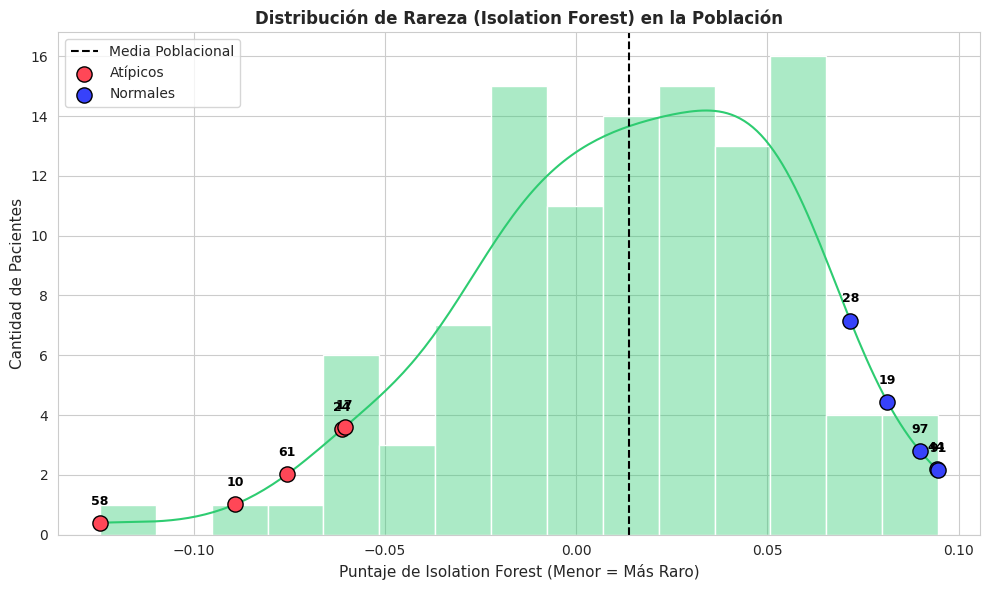

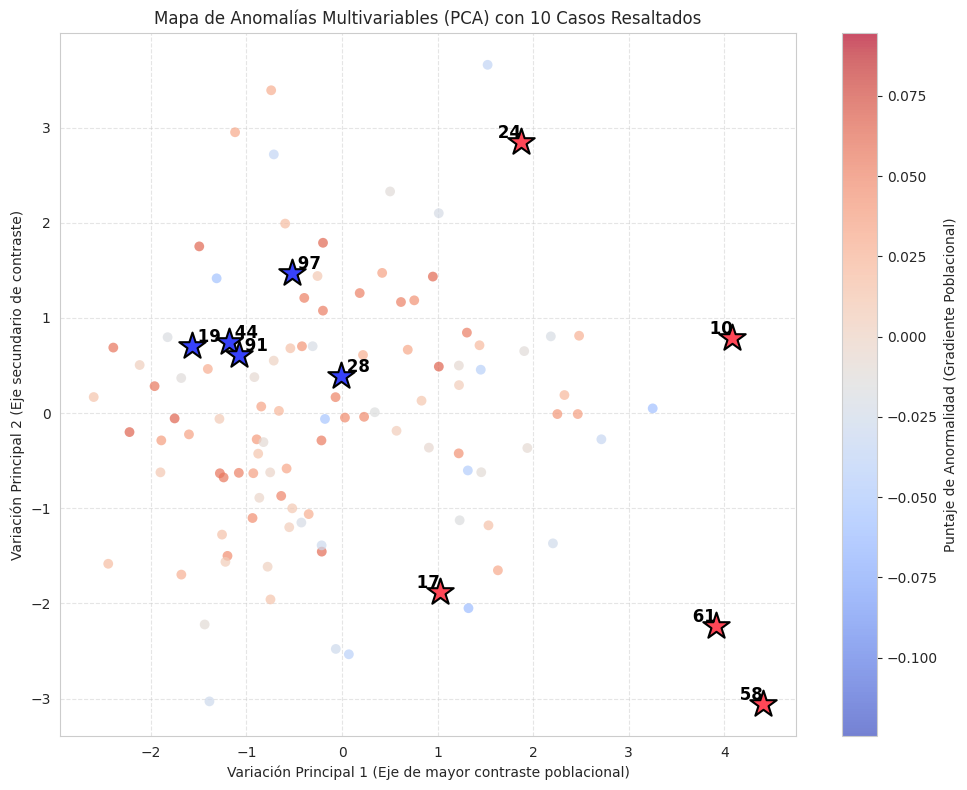


--- GRÁFICAS Y PERFILES ACTUALIZADOS ---


In [14]:
print("\nBUSQUEDA DE PERFILES CLÍNICOS")

# 1. Selección y limpieza inicial de variables
# Definimos la lista exacta de características clínicas y de estilo de vida que el algoritmo usará para juzgar qué tan "normal" o "raro" es un paciente.
cols_score = [
    'Microbiota_Stress', 'Categoria_Glucosa', 'Riesgo_cintura', '5.4',
    'Diet_Score', 'Lifestyle_Score', 'IMC',
    '4.1 ¿Cuál de las siguientes imágenes representa mejor el tipo de heces que tienes la mayoría de los días?',
    '4.2', '1.3', 'Taquicardia_reposo', 'Temperatura (°C)', 'Fitzpatrick Scale'
]

# Validación de seguridad: Comparamos nuestra lista ideal con las columnas que realmente existen en la base de datos (df_final). Si por algún error borramos una columna del Excel antes, esta línea evita que el código explote.
cols_score = [col for col in cols_score if col in df_final.columns]

# 2. Estandarización de los datos (z-scores)
# ¿Por qué hacemos esto? No podemos comparar peras con manzanas.
# El IMC va de 18 a 40, pero la Temperatura va de 35 a 38. El algoritmo se confundiría con escalas tan distintas. StandardScaler convierte todo a "Z-scores" (donde 0 es el promedio exacto poblacional).
scaler_z = StandardScaler()
df_raw_score = df_final[cols_score].copy()

# Tratamiento de datos faltantes (Imputación): Si un paciente no llenó un dato, rellenamos ese hueco con la mediana de la población. Usamos la mediana y no el promedio porque la mediana no se deja engañar por valores extremos.
for col in cols_score:
    df_raw_score[col] = df_raw_score[col].fillna(df_raw_score[col].median())

# Aplicamos la transformación matemática y guardamos los resultados en un nuevo DataFrame
Z_pacientes = scaler_z.fit_transform(df_raw_score)
df_Z = pd.DataFrame(Z_pacientes, columns=cols_score, index=df_final.index)

# 3. Detección de anomalías (Isolation Forest)
# Isolation Forest funciona creando árboles de decisión aleatorios que intentan aislar a cada paciente. Si un paciente es muy raro, requiere muy pocas preguntas (ramas) para quedar aislado del resto. Si es muy normal, está escondido en medio del rebaño y es difícil de aislar.
# contamination='auto' permite que el algoritmo decida matemáticamente el umbral de rareza basándose en la dispersión real de los datos, sin forzar cuotas.
# random_state=42 asegura que el resultado sea reproducible cada vez que se corra.
iso_forest = IsolationForest(contamination='auto', random_state=42)

# Entrenamos el modelo con nuestros datos estandarizados
iso_forest.fit(df_Z)

# decision_function nos da una calificación numérica continua del aislamiento
df_final['Nivel_Rareza'] = iso_forest.decision_function(df_Z)

# Ordenamos toda la base de datos tomando esta calificación como criterio
df_ordenado = df_final.sort_values('Nivel_Rareza', ascending=True)

# Extraemos los dos polos opuestos de la población para analizarlos:
top_5_interesantes = df_ordenado.head(5)
top_5_menos_interesantes = df_ordenado.tail(5)

# 4. Descubriendo el porqué de cada paciente
# ==============================================================================
def obtener_habitos_clave(paciente_idx, es_anomalia=True):
    """
    Esta función analiza el perfil Z-score de un individuo para explicar por qué
    el modelo lo clasificó de esa forma.
    """
    # Extraemos el perfil completo de este paciente específico
    z_scores_paciente = df_Z.loc[paciente_idx]

    # Lógica inteligente:
    if es_anomalia:
        # Si es un caso raro, queremos saber en qué variables se ALEJÓ más del cero.
        # abs() convierte todo a positivo para que los extremos (altos o bajos) pesen igual.
        top_desviaciones = z_scores_paciente.abs().sort_values(ascending=False).head(3)
    else:
        # Si es un caso promedio, queremos saber qué variables son CASI CERO (idénticas a la media).
        top_desviaciones = z_scores_paciente.abs().sort_values(ascending=True).head(3)

    explicacion = []
    # Recorremos esas 3 variables top para armar un texto legible
    for col, valor_abs in top_desviaciones.items():
        valor_real = df_final.loc[paciente_idx, col] # El valor real antes de estandarizar
        z_val = z_scores_paciente[col] # El Z-score (con su signo original)

        if es_anomalia:
            # Si el Z-score es positivo, estaba por encima de la media. Si es negativo, por debajo.
            tendencia = "anormalmente ALTO" if z_val > 0 else "anormalmente BAJO"
        else:
            tendencia = "idéntico al promedio"

        # Limpieza estética para imprimir sin textos gigantes
        nombre_col = "Heces Bristol" if "imágenes" in col else col
        explicacion.append(f"- {nombre_col} ({tendencia}, valor original: {valor_real})")

    return explicacion

# 5. Reporte final en consola
print("\n" + "="*70)
print(" LOS 5 PACIENTES MÁS INTERESANTES (Casos Atípicos / Extremos)")
print("="*70)
for idx, row in top_5_interesantes.iterrows():
    print(f"\nPaciente ID: {idx}")
    print(f"Puntaje de Rareza: {row['Nivel_Rareza']:.3f} (Muy negativo)")
    print("Sus variables más extremas son:")
    # Pasamos es_anomalia=True porque son los casos raros
    for habito in obtener_habitos_clave(idx, es_anomalia=True):
        print(f"    {habito}")

print("\n" + "="*70)
print(" LOS 5 PACIENTES MENOS INTERESANTES (El Promedio Poblacional)")
print("="*70)
for idx, row in top_5_menos_interesantes.iterrows():
    print(f"\nPaciente ID: {idx}")
    print(f"Puntaje de Rareza: {row['Nivel_Rareza']:.3f} (Positivo/Normal)")
    print("Sus variables más cercanas al promedio poblacional:")
    # Pasamos es_anomalia=False porque son los casos normales
    for habito in obtener_habitos_clave(idx, es_anomalia=False):
         print(f"    {habito}")
print("\n" + "="*70)

# 6. Visualizaciones estadísticas avanzadas
sns.set_style("whitegrid") # Añade una cuadrícula gris tenue de fondo

# GRÁFICA 1: Curva de Densidad- Distribución de la Anormalidad
plt.figure(figsize=(10, 6))

# Dibujamos el histograma base y la curva suave (Kernel Density Estimate)
# Esto nos muestra visualmente cuántos pacientes caen en cada nivel de rareza.
ax = sns.histplot(data=df_final, x='Nivel_Rareza', kde=True,
                  color='#2ecc71', alpha=0.4, bins=15, edgecolor='white')

# Truco de interpolación: Queremos que los puntos de los pacientes floten exactamente sobre el borde verde de la campana. Para eso, extraemos las coordenadas (X, Y) de la línea que Seaborn acaba de dibujar.
linea_kde = ax.lines[0]
x_curva = linea_kde.get_xdata() # Todos los puntos horizontales de la línea
y_curva = linea_kde.get_ydata() # Todas las alturas correspondientes

# Dibujamos una línea punteada que representa el centro de gravedad poblacional
media_rareza = df_final['Nivel_Rareza'].mean()
plt.axvline(media_rareza, color='black', linestyle='--', linewidth=1.5, label='Media Poblacional')

# Colocamos las 5 estrellas rojas (Los más RAROS) en la gráfica
for idx, row in top_5_interesantes.iterrows():
    x_val = row['Nivel_Rareza']
    # np.interp busca nuestro valor X en la curva y nos dice matemáticamente qué altura (Y) le corresponde, para que el punto encaje perfecto.
    y_val = np.interp(x_val, x_curva, y_curva)

    plt.scatter(x_val, y_val, color='#ff4757', s=120, edgecolor='black', zorder=5,
                label='Atípicos' if idx == top_5_interesantes.index[0] else "")
    plt.text(x_val, y_val + (ax.get_ylim()[1]*0.03), f'{idx}', color='black',
             ha='center', va='bottom', fontsize=9, weight='bold')

# Colocamos las 5 estrellas azules (Los más NORMALES) en la gráfica
for idx, row in top_5_menos_interesantes.iterrows():
    x_val = row['Nivel_Rareza']
    y_val = np.interp(x_val, x_curva, y_curva)

    plt.scatter(x_val, y_val, color='#3742fa', s=120, edgecolor='black', zorder=5,
                label='Normales' if idx == top_5_menos_interesantes.index[0] else "")
    plt.text(x_val, y_val + (ax.get_ylim()[1]*0.03), f'{idx}', color='black',
             ha='center', va='bottom', fontsize=9, weight='bold')

plt.title('Distribución de Rareza (Isolation Forest) en la Población', fontsize=12, weight='bold')
plt.xlabel('Puntaje de Isolation Forest (Menor = Más Raro)', fontsize=11)
plt.ylabel('Cantidad de Pacientes', fontsize=11)

handles, labels = ax.get_legend_handles_labels()
plt.legend(handles, labels, loc='upper left')
plt.tight_layout()
plt.show()

# GRÁFICA 2: Análisis de Componentes Principales (PCA) - Mapa Multivariable
# Tenemos más de 10 variables clínicas. Los humanos solo podemos ver en 2D o 3D.
# PCA comprime todas esas variables y extrae las 2 dimensiones (Componente_1 y Componente_2) que concentran la mayor cantidad de información y varianza del estudio.
pca = PCA(n_components=2)
componentes = pca.fit_transform(Z_pacientes)
df_pca = pd.DataFrame(componentes, columns=['Componente_1', 'Componente_2'], index=df_final.index)

plt.figure(figsize=(10, 8))

# Graficamos absolutamente toda la población.
# c=df_final['Nivel_Rareza'] pinta cada punto dependiendo de su calificación clínica.
# El 'cmap' coolwarm crea el gradiente: Las zonas azules son los clústeres donde se agrupa la gente normal. Las zonas rojas son desiertos donde quedan varados los casos raros.
scatter = plt.scatter(df_pca['Componente_1'], df_pca['Componente_2'],
                      c=df_final['Nivel_Rareza'], cmap='coolwarm', s=50, alpha=0.7, edgecolors='none')

# Superponemos estrellas gigantes para resaltar dónde cayeron nuestros top 5 extremos
color_atipicos = '#ff4757'
for idx, row in top_5_interesantes.iterrows():
    plt.scatter(df_pca.loc[idx, 'Componente_1'], df_pca.loc[idx, 'Componente_2'],
                s=400, color=color_atipicos, marker='*', edgecolors='black', linewidth=1.5, zorder=10)
    plt.text(df_pca.loc[idx, 'Componente_1'], df_pca.loc[idx, 'Componente_2'], f' {idx}',
             color='black', fontsize=12, fontweight='bold', va='bottom', ha='right', zorder=11)

# Superponemos estrellas gigantes para los top 5 normales
color_normales = '#3742fa'
for idx, row in top_5_menos_interesantes.iterrows():
    plt.scatter(df_pca.loc[idx, 'Componente_1'], df_pca.loc[idx, 'Componente_2'],
                s=400, color=color_normales, marker='*', edgecolors='black', linewidth=1.5, zorder=10)
    plt.text(df_pca.loc[idx, 'Componente_1'], df_pca.loc[idx, 'Componente_2'], f' {idx}',
             color='black', fontsize=12, fontweight='bold', va='bottom', ha='left', zorder=11)

# Barra lateral para que el usuario entienda qué significa la transición de colores del fondo
colorbar = plt.colorbar(scatter)
colorbar.set_label('Puntaje de Anormalidad (Gradiente Poblacional)')

plt.grid(linestyle='--', alpha=0.5)
plt.title('Mapa de Anomalías Multivariables (PCA) con 10 Casos Resaltados')
plt.xlabel('Variación Principal 1 (Eje de mayor contraste poblacional)')
plt.ylabel('Variación Principal 2 (Eje secundario de contraste)')
plt.tight_layout()
plt.show()

print("\n--- GRÁFICAS Y PERFILES ACTUALIZADOS ---")

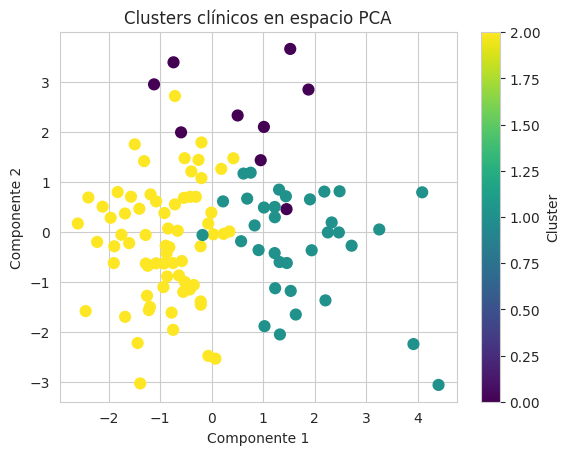

In [15]:
# pueden probar 2–4 clusters
gmm = GaussianMixture(n_components=3, random_state=42)

df_final["Cluster"] = gmm.fit_predict(df_Z)



plt.figure()

plt.scatter(df_pca['Componente_1'], df_pca['Componente_2'],
            c=df_final["Cluster"], cmap='viridis', s=60)

plt.title("Clusters clínicos en espacio PCA")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")

plt.colorbar(label="Cluster")
plt.show()

In [16]:
variables_clave = [
    'IMC', 'Diet_Score', 'Microbiota_Stress',
    'Lifestyle_Score', 'Categoria_Glucosa', 'Riesgo_cintura'
]

perfil_clusters = df_final.groupby("Cluster")[variables_clave].mean()

print("\nPERFIL PROMEDIO POR CLUSTER:")
print(perfil_clusters)


PERFIL PROMEDIO POR CLUSTER:
               IMC  Diet_Score  Microbiota_Stress  Lifestyle_Score  Categoria_Glucosa  Riesgo_cintura
Cluster                                                                                              
0        26.951428   19.333333           7.111111        -6.555556           0.000000        0.666667
1        31.192954    0.970588          15.558824       -20.176471           0.323529        1.000000
2        23.275048   10.485294          14.808824       -19.426471           0.279412        0.000000


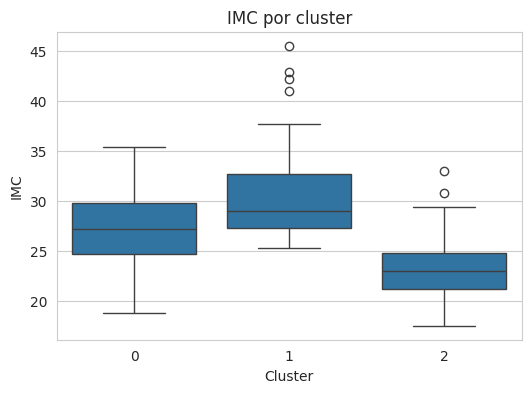

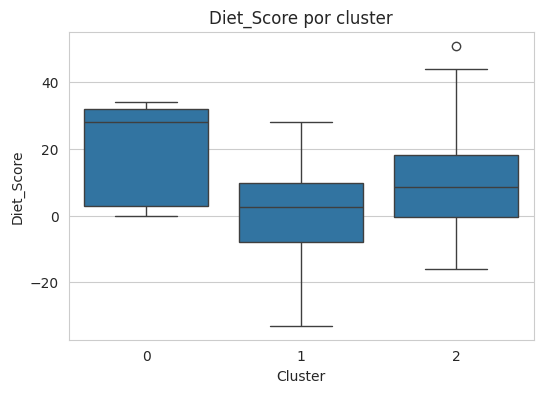

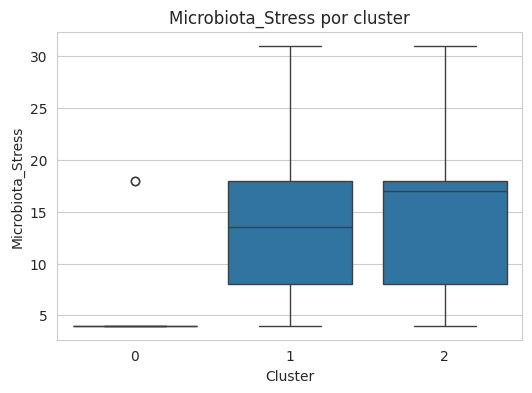

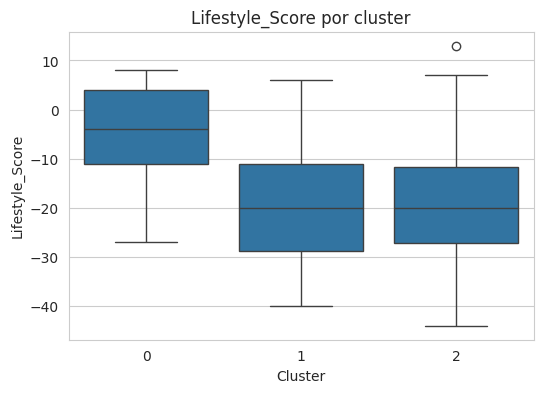

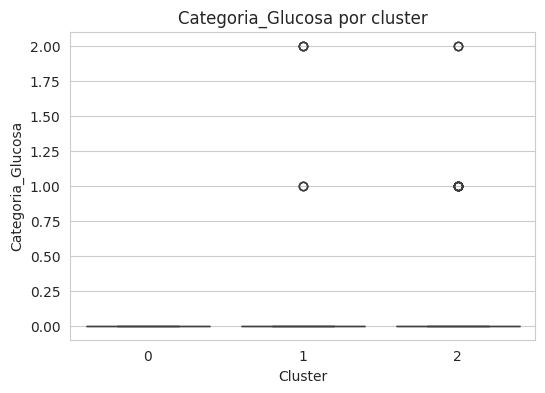

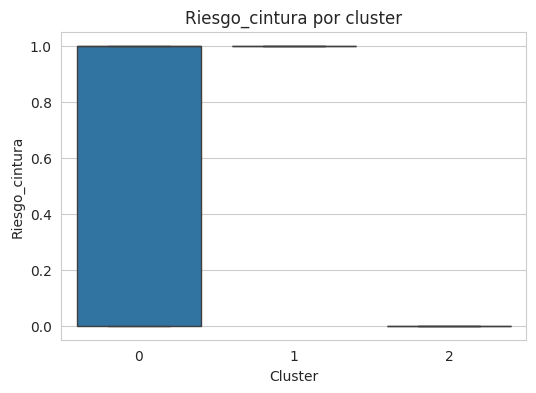

In [17]:
import seaborn as sns

for var in variables_clave:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="Cluster", y=var, data=df_final)
    plt.title(f"{var} por cluster")
    plt.show()

In [18]:
tabla_cluster_anomalia = pd.crosstab(df_final["Cluster"], df_final["Nivel_Rareza"] < 0)

print("\nRELACIÓN CLUSTER vs ANOMALÍA:")
print(tabla_cluster_anomalia)


RELACIÓN CLUSTER vs ANOMALÍA:
Nivel_Rareza  False  True 
Cluster                   
0                 4      5
1                17     17
2                51     17


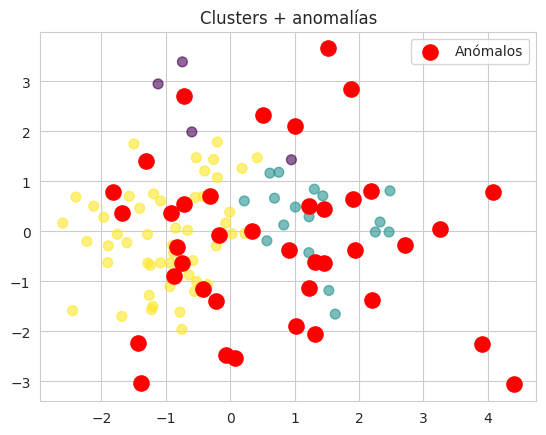

In [19]:
plt.figure()

plt.scatter(df_pca['Componente_1'], df_pca['Componente_2'],
            c=df_final["Cluster"], cmap='viridis', s=50, alpha=0.6)

# resaltar anómalos
anomalias = df_final[df_final["Nivel_Rareza"] < 0]

plt.scatter(df_pca.loc[anomalias.index, 'Componente_1'],
            df_pca.loc[anomalias.index, 'Componente_2'],
            color='red', s=120, label='Anómalos')

plt.legend()
plt.title("Clusters + anomalías")
plt.show()

In [20]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

X = df_Z
y = df_final["Cluster"]

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X, y)

importancias = pd.Series(rf.feature_importances_, index=df_Z.columns)
importancias = importancias.sort_values(ascending=False)

print("\nIMPORTANCIA DE VARIABLES:")
print(importancias)


IMPORTANCIA DE VARIABLES:
Riesgo_cintura                                                                                               0.398401
IMC                                                                                                          0.248327
Microbiota_Stress                                                                                            0.070340
Diet_Score                                                                                                   0.057487
Lifestyle_Score                                                                                              0.055076
4.1 ¿Cuál de las siguientes imágenes representa mejor el tipo de heces que tienes la mayoría de los días?    0.044619
4.2                                                                                                          0.028690
Fitzpatrick Scale                                                                                            0.027376
Temperatura (°C)             

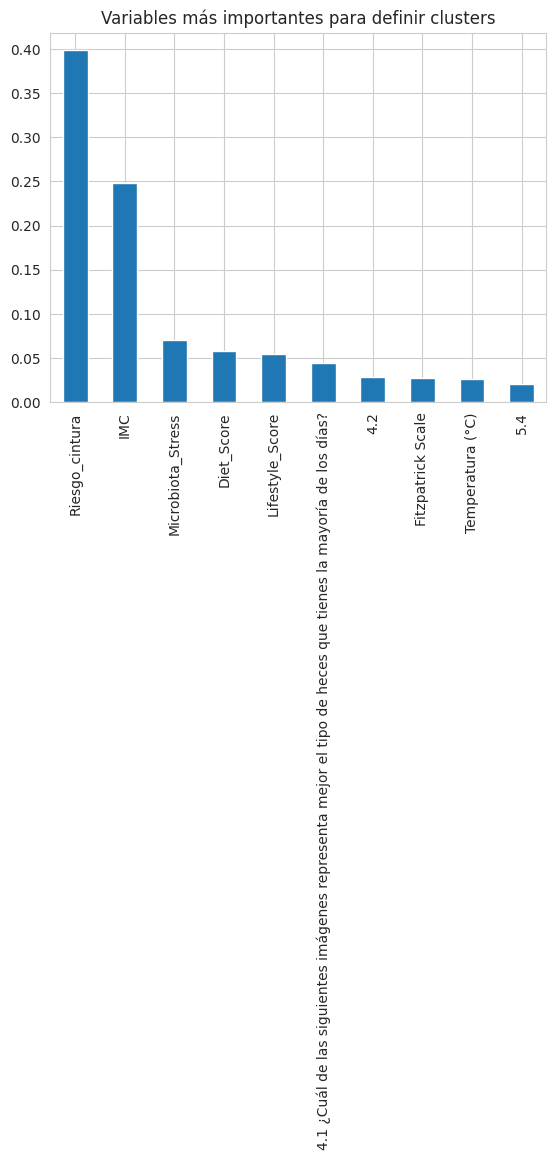

In [21]:
plt.figure()
importancias.head(10).plot(kind='bar')
plt.title("Variables más importantes para definir clusters")
plt.show()

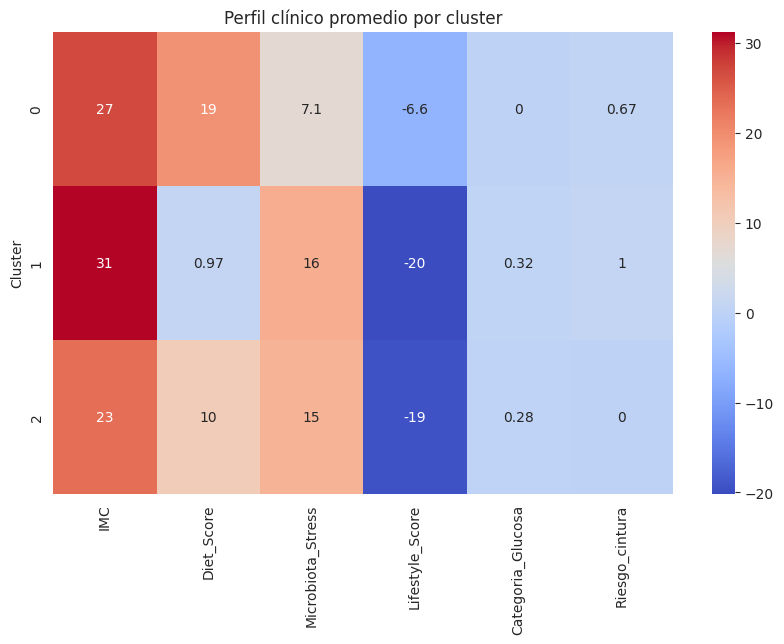

In [22]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(perfil_clusters, annot=True, cmap="coolwarm")

plt.title("Perfil clínico promedio por cluster")
plt.show()

In [23]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=df_Z.columns
)

print("\nCARGAS DEL PCA:")
print(loadings.sort_values(by="PC1", ascending=False))


CARGAS DEL PCA:
                                                         PC1       PC2
Riesgo_cintura                                      0.565099  0.058052
IMC                                                 0.548293 -0.059428
Fitzpatrick Scale                                   0.344513  0.254349
4.1 ¿Cuál de las siguientes imágenes representa...  0.235248  0.430938
4.2                                                 0.167654  0.328363
Categoria_Glucosa                                   0.102117 -0.363633
Taquicardia_reposo                                  0.095968 -0.115479
Microbiota_Stress                                   0.063554 -0.240592
1.3                                                -0.070226 -0.003700
Lifestyle_Score                                    -0.097301  0.517801
5.4                                                -0.124692 -0.068300
Temperatura (°C)                                   -0.167712  0.234279
Diet_Score                                         -0.310076

In [24]:
print("\nTop variables PC1:")
print(loadings["PC1"].abs().sort_values(ascending=False).head(5))

print("\nTop variables PC2:")
print(loadings["PC2"].abs().sort_values(ascending=False).head(5))


Top variables PC1:
Riesgo_cintura                                                                                               0.565099
IMC                                                                                                          0.548293
Fitzpatrick Scale                                                                                            0.344513
Diet_Score                                                                                                   0.310076
4.1 ¿Cuál de las siguientes imágenes representa mejor el tipo de heces que tienes la mayoría de los días?    0.235248
Name: PC1, dtype: float64

Top variables PC2:
Lifestyle_Score                                                                                              0.517801
4.1 ¿Cuál de las siguientes imágenes representa mejor el tipo de heces que tienes la mayoría de los días?    0.430938
Categoria_Glucosa                                                                                           